In [0]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.window import Window

spark = SparkSession.builder.appName("HealthcareAnalytics").getOrCreate()

In [0]:
spark.sql("DROP TABLE IF EXISTS healthcare_bronze_patients")
spark.sql("DROP TABLE IF EXISTS healthcare_bronze_doctors")
spark.sql("DROP TABLE IF EXISTS healthcare_bronze_appointments")
spark.sql("DROP TABLE IF EXISTS healthcare_bronze_preferences")
spark.sql("DROP TABLE IF EXISTS healthcare_silver_preferences")
spark.sql("DROP TABLE IF EXISTS healthcare_silver_fact")
spark.sql("DROP TABLE IF EXISTS healthcare_delta_table")
spark.sql("DROP TABLE IF EXISTS healthcare_delta_sql")
spark.sql("DROP TABLE IF EXISTS healthcare_managed")

DataFrame[]

In [0]:
patients_df = spark.read.option("header","true").csv("/Volumes/pysparkazure_7405618553170348/default/practice/patients.csv")
doctors_df = spark.read.option("header","true").csv("/Volumes/pysparkazure_7405618553170348/default/practice/doctors.csv")
appointments_df = spark.read.option("header","true").csv("/Volumes/pysparkazure_7405618553170348/default/practice/appointments.csv")
preferences_df = spark.read.option("multiline","true").json("/Volumes/pysparkazure_7405618553170348/default/practice/patient_preferences.json")

In [0]:
patients_df.printSchema()
doctors_df.printSchema()
appointments_df.printSchema()
preferences_df.printSchema()

root
 |-- patient_id: string (nullable = true)
 |-- patient_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- age: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- insurance_status: string (nullable = true)

root
 |-- doctor_id: string (nullable = true)
 |-- doctor_name: string (nullable = true)
 |-- department: string (nullable = true)
 |-- city: string (nullable = true)
 |-- consultation_fee: string (nullable = true)

root
 |-- appointment_id: string (nullable = true)
 |-- patient_id: string (nullable = true)
 |-- doctor_id: string (nullable = true)
 |-- appointment_date: string (nullable = true)
 |-- diagnosis: string (nullable = true)
 |-- bill_amount: string (nullable = true)
 |-- status: string (nullable = true)

root
 |-- contact: struct (nullable = true)
 |    |-- email: string (nullable = true)
 |    |-- phone: string (nullable = true)
 |-- patient_id: string (nullable = true)
 |-- preferred_hospital

In [0]:
patients_df.write.format("delta").mode("overwrite").saveAsTable("healthcare_bronze_patients")
doctors_df.write.format("delta").mode("overwrite").saveAsTable("healthcare_bronze_doctors")
appointments_df.write.format("delta").mode("overwrite").saveAsTable("healthcare_bronze_appointments")
preferences_df.write.format("delta").mode("overwrite").saveAsTable("healthcare_bronze_preferences")

In [0]:
patients_df = patients_df.fillna("Unknown")
doctors_df = doctors_df.fillna("Unknown")
appointments_df = appointments_df.fillna("Unknown")

doctors_df = doctors_df.withColumnRenamed("city","doctor_city")

In [0]:
preferences_flat = preferences_df.select(
    "patient_id",
    "preferred_hospital",
    col("contact.phone").alias("phone"),
    col("contact.email").alias("email")
)

patient_pref_df = patients_df.join(preferences_flat,"patient_id","left")
appointment_patient_df = appointments_df.join(patient_pref_df,"patient_id","left")
final_df = appointment_patient_df.join(doctors_df,"doctor_id","left")

In [0]:
final_df = final_df.withColumn("bill_amount",col("bill_amount").cast("double"))
final_df = final_df.withColumn("consultation_fee",col("consultation_fee").cast("double"))
final_df = final_df.withColumn("age",col("age").cast("int"))
final_df = final_df.withColumn("final_bill",col("bill_amount")+col("consultation_fee"))
final_df = final_df.withColumn("appointment_date",to_date("appointment_date"))
final_df = final_df.withColumn("appointment_month",date_format("appointment_date","yyyy-MM"))
final_df = final_df.withColumn(
    "patient_age_group",
    when(col("age") >= 50,"Senior").when(col("age") >= 30,"Adult").otherwise("Young")
)

In [0]:
patient_pref_df.write.format("delta").mode("overwrite").saveAsTable("healthcare_silver_preferences")
final_df.write.format("delta").mode("overwrite").saveAsTable("healthcare_silver_fact")

final_df.createOrReplaceTempView("healthcare_view")

In [0]:
spark.sql("SELECT SUM(final_bill) total_hospital_revenue FROM healthcare_view").show()
spark.sql("SELECT department,SUM(final_bill) revenue FROM healthcare_view GROUP BY department ORDER BY revenue DESC").show()
spark.sql("SELECT city,SUM(final_bill) revenue FROM healthcare_view GROUP BY city ORDER BY revenue DESC").show()
spark.sql("SELECT * FROM healthcare_view WHERE status='Completed'").show()
spark.sql("SELECT patient_name,SUM(final_bill) billing FROM healthcare_view GROUP BY patient_name ORDER BY billing DESC").show()

+----------------------+
|total_hospital_revenue|
+----------------------+
|               69200.0|
+----------------------+

+-----------+-------+
| department|revenue|
+-----------+-------+
| Cardiology|33000.0|
|Orthopedics|21500.0|
|Dermatology| 6500.0|
|  Neurology| 5500.0|
| Pediatrics| 2700.0|
+-----------+-------+

+---------+-------+
|     city|revenue|
+---------+-------+
|Hyderabad|23000.0|
|    Delhi|21500.0|
|     Pune|10000.0|
|Bangalore| 5500.0|
|    Kochi| 3500.0|
|   Mumbai| 3000.0|
|  Chennai| 2700.0|
+---------+-------+

+---------+----------+--------------+----------------+--------------+-----------+---------+------------+---------+-----------+---+------+----------------+------------------+----------+--------------+-----------+-----------+-----------+----------------+----------+-----------------+-----------------+
|doctor_id|patient_id|appointment_id|appointment_date|     diagnosis|bill_amount|   status|patient_name|     city|      state|age|gender|insurance_status|

In [0]:
doctor_revenue = final_df.groupBy("doctor_name").agg(sum("final_bill").alias("revenue"))
doctor_revenue.withColumn("rank",rank().over(Window.orderBy(desc("revenue")))).show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-----------+-------+----+
|doctor_name|revenue|rank|
+-----------+-------+----+
| Dr. Suresh|21500.0|   1|
|  Dr. Kiran|19500.0|   2|
| Dr. Ramesh|13500.0|   3|
|  Dr. Anita| 6500.0|   4|
|  Dr. Priya| 5500.0|   5|
|  Dr. Meera| 2700.0|   6|
+-----------+-------+----+



In [0]:
department_revenue = final_df.groupBy("department").agg(sum("final_bill").alias("revenue"))
department_revenue.withColumn("rank",rank().over(Window.orderBy(desc("revenue")))).show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-----------+-------+----+
| department|revenue|rank|
+-----------+-------+----+
| Cardiology|33000.0|   1|
|Orthopedics|21500.0|   2|
|Dermatology| 6500.0|   3|
|  Neurology| 5500.0|   4|
| Pediatrics| 2700.0|   5|
+-----------+-------+----+



In [0]:
patient_revenue = final_df.groupBy("patient_name").agg(sum("final_bill").alias("revenue"))
patient_rank = patient_revenue.withColumn("rank",rank().over(Window.orderBy(desc("revenue"))))
patient_rank.filter(col("rank") <= 3).show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+------------+-------+----+
|patient_name|revenue|rank|
+------------+-------+----+
| Sneha Patel|21500.0|   1|
|Rahul Sharma|16000.0|   2|
|  Neha Singh|10000.0|   3|
+------------+-------+----+



In [0]:
doctor_department_revenue = final_df.groupBy("department","doctor_name").agg(sum("final_bill").alias("revenue"))
doctor_department_revenue.withColumn(
    "rank",
    rank().over(Window.partitionBy("department").orderBy(desc("revenue")))
).filter(col("rank")==1).show()

+-----------+-----------+-------+----+
| department|doctor_name|revenue|rank|
+-----------+-----------+-------+----+
| Cardiology|  Dr. Kiran|19500.0|   1|
|Dermatology|  Dr. Anita| 6500.0|   1|
|  Neurology|  Dr. Priya| 5500.0|   1|
|Orthopedics| Dr. Suresh|21500.0|   1|
| Pediatrics|  Dr. Meera| 2700.0|   1|
+-----------+-----------+-------+----+



In [0]:
daily_revenue = final_df.groupBy("appointment_date").agg(sum("final_bill").alias("daily_revenue"))
daily_revenue.withColumn(
    "running_revenue",
    sum("daily_revenue").over(Window.orderBy("appointment_date"))
).show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+----------------+-------------+---------------+
|appointment_date|daily_revenue|running_revenue|
+----------------+-------------+---------------+
|      2026-06-01|      12000.0|        12000.0|
|      2026-06-02|      17500.0|        29500.0|
|      2026-06-03|      12700.0|        42200.0|
|      2026-06-04|      10500.0|        52700.0|
|      2026-06-05|      16500.0|        69200.0|
+----------------+-------------+---------------+



In [0]:
final_df.write.format("delta").mode("overwrite").save("/Volumes/pysparkazure_7405618553170348/default/practice/healthcare_delta")
final_df.write.format("delta").mode("overwrite").saveAsTable("healthcare_delta_table")

In [0]:
spark.sql("""
CREATE TABLE healthcare_delta_sql
USING DELTA
AS SELECT * FROM healthcare_silver_fact
""")

DataFrame[num_affected_rows: bigint, num_inserted_rows: bigint]

In [0]:
spark.sql("DESCRIBE HISTORY healthcare_delta_table").show(truncate=False)

+-------+-------------------+---------------+-------------------------------------------------------+---------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----+------------------+------------------------------------+------------------------+-----------+-----------------+-------------+----------------------------------------------------------------------------------------------------------------------------------------+------------+------------------------------------------+
|version|timestamp          |userId         |userName                                               |operation                        |operationParameters                                                                                                                                                                

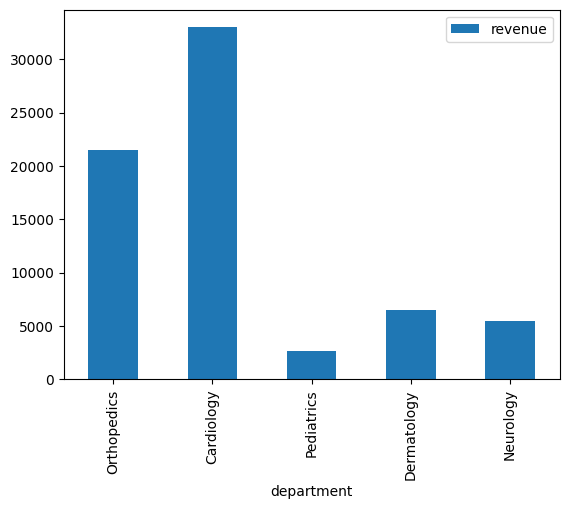

In [0]:
import pandas as pd
import matplotlib.pyplot as plt

final_df.groupBy("department").agg(sum("final_bill").alias("revenue")).toPandas().plot(kind="bar",x="department",y="revenue")
plt.show()

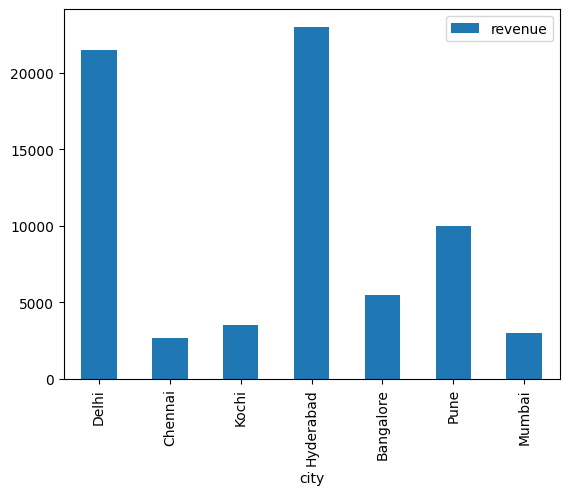

In [0]:
final_df.groupBy("city").agg(sum("final_bill").alias("revenue")).toPandas().plot(kind="bar",x="city",y="revenue")
plt.show()

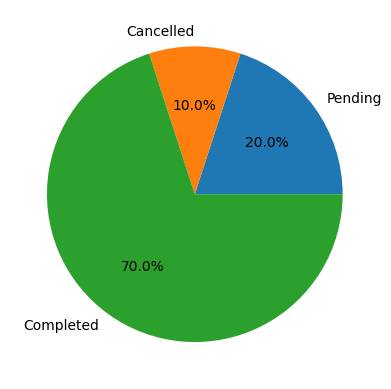

In [0]:
status_df = final_df.groupBy("status").count().toPandas()
plt.pie(status_df["count"],labels=status_df["status"],autopct="%1.1f%%")
plt.show()

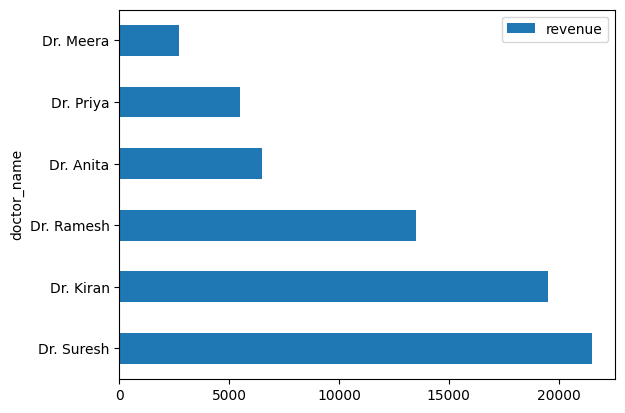

In [0]:
final_df.groupBy("doctor_name").agg(sum("final_bill").alias("revenue")).orderBy(desc("revenue")).toPandas().plot(kind="barh",x="doctor_name",y="revenue")
plt.show()

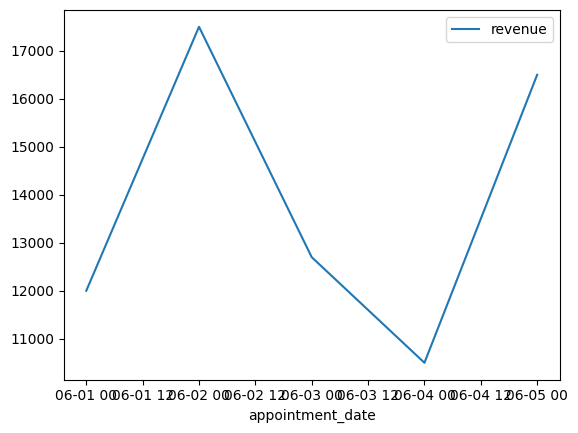

In [0]:
final_df.groupBy("appointment_date").agg(sum("final_bill").alias("revenue")).orderBy("appointment_date").toPandas().plot(x="appointment_date",y="revenue")
plt.show()

In [0]:
final_df.write.mode("overwrite").saveAsTable("healthcare_managed")
final_df.write.format("delta").mode("overwrite").save("/Volumes/pysparkazure_7405618553170348/default/practice/healthcare_external")

final_df.createOrReplaceTempView("temp_healthcare_view")